## Insight
### 1. 데이터 기본 정보 — 결측치
- 메일 본문(`body`)은 결측이 없고 대부분의 정보가 포함되어 있어 텍스트 분류 모델의 주요 feature로 활용하기에 안정적임.
- `receiver`는 모델 학습에 큰 영향을 주지 않을 가능성이 낮기 때문에 결측치를 제거하거나 `unknown`으로 채우는 것이 합리적임.
- `subject`의 결측 28개는 전체 대비 매우 작은 비율이므로 제거해도 무방함.

---

### 2. label(피싱/정상)의 분포 상태
- 약간의 class imbalance가 존재함  
→ 모델 학습 시 `class_weight` 옵션을 활용하여 균형을 조정하는 것이 효과적임.

---

### 3. 날짜(date) 컬럼
- 대부분의 이메일이 특정 하루(2008-08-05 또는 2008-08-06)에 집중되어 있음  
→ 날짜 정보는 변별력이 거의 없으므로 `date` 컬럼을 제거(drop)하는 것을 추천함.

---

### 4. URL 포함 여부 분포 해석
- URL을 포함한 이메일이 URL이 없는 이메일보다 **약 두 배 이상 많음**.
- 피싱 이메일은 URL을 통해 악성 사이트로 유도하는 경우가 많기 때문에 **URL 포함 여부는 피싱 여부를 판단하는 feature**로 활용할 수 있음


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

df = pd.read_csv("../data/CEAS_08.csv")

# get info
print(df.info())
print(df.isnull().sum())

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB
None
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64
                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                                 

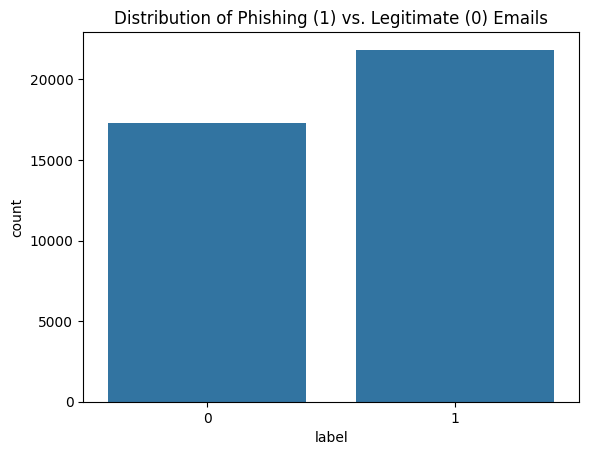

In [2]:
# Distribution of the label column
sns.countplot(x='label', data=df)
plt.title('Distribution of Phishing (1) vs. Legitimate (0) Emails')
plt.show()

In [3]:
# Analyzing the date column
df['date'] = pd.to_datetime(df['date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce', utc=True)
print(df['date'].dtype)

datetime64[ns, UTC]


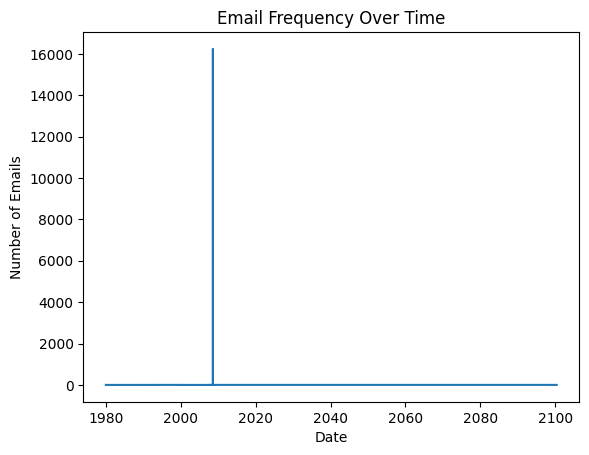

In [4]:
# Creating separate columns for Date and Time
df['Date'] = df['date'].dt.date
df['Time'] = df['date'].dt.time

# Handling any remaining NaT values (if any)
df = df.dropna(subset=['date'])

# Plotting the distribution of emails over time
df['Date'].value_counts().sort_index().plot()
plt.title('Email Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Emails')
plt.show()

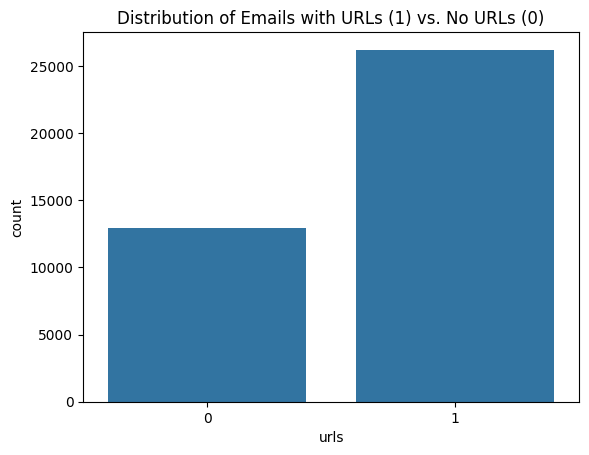

In [5]:
# Distribution of URLs in the emails
sns.countplot(x='urls', data=df)
plt.title('Distribution of Emails with URLs (1) vs. No URLs (0)')
plt.show()